## Answers for week 6

* Name: Wendy Oosterhof
* Username: wroosterhof
* Student s-number: S6328091
* Group: AS6

In [ ]:
#6.1
import numpy as np
from astropy.io import fits
from scipy import stats
from matplotlib.pyplot import figure, show
from matplotlib import pyplot as plt
from matplotlib.axes import Axes

hdulist = fits.open('m101.fits')
hdulist.info()
print("There are 2 HDUs in this FITS file.")
print("The HDU containing the image data is 0.")
print("The type of this data is int 16.") #The number type is the format.

hdr = hdulist[0].header

for key in hdr[:5]:
    print(f"{key:18s}={hdr[key]}")
print("The value of BIPTIX= is 16, so yes it is inline with the previous questions.")

dat = hdulist[0].data
print("This data structure is a type: ", type(dat))
print(f"The shape of this data is: {dat.shape}, which is inline with the information from .info")
print(hdr["NAXIS1"], hdr["NAXIS2"])
print(f"The dtype of dat is: {dat.dtype}")
print(f"dtype defines the type of data stored in an array. In this case {dat.dtype} stands for int16")#Number of bites for the 2i
#and the > means that the most significant byte is stored first in memory.
print("This means it is inline with the value at BITPIX=")

flatdat = dat.flatten()
mode, count = stats.mode(flatdat)
print(f"Mode = {mode}")
nobs, (minval, maxval), mean, var, skew, kurt = stats.describe(flatdat)
print(f"N={nobs}, min={minval}, max = {maxval}, mean = {mean}, std = {var**0.5}")
median= np.median(flatdat)
print(f"Median of the data: {median}")

fig =figure(figsize = (8,6))
frame = fig.add_subplot(1,1,1)

frame.hist(flatdat, bins = 50, color = "orchid")
frame.axvline(mean, color = "red", label = "mean")
frame.axvline(median, color = "purple", label = "median")
frame.axvline(mode, color = "blue", label = "mode")
frame.legend()
show()

hdr["BUNIT"] = "Counts"

newdat = np.asarray(dat, dtype=float)
newmean = np.mean(newdat)

fig = figure(figsize = (8,6))
frame = fig.add_subplot(1,1,1)
plt.imshow(newdat, interpolation = "none", origin = "lower", cmap = "Blues", vmin = newmean)
frame.set_xlabel(hdr["CTYPE1"])
frame.set_ylabel(hdr["CTYPE2"])
plt.colorbar(label = hdr["BUNIT"])

hdulistout = fits.PrimaryHDU(newdat)
hdulistout.header = hdr    # We can copy the old header
hdulistout.writeto('m101_2.fits', overwrite=True, output_verify='ignore')


hdulist.close()

In [118]:
#6.3

hdulist = fits.open('m101_2.fits') #Using the remade version from 6.1
hdulist.info()

dat = hdulist[0].data
newdat = dat[:20,:20]

RMS = ((1/400)*(np.sum((newdat**2))))**(0.5)
print(f"The Root mean square is: {RMS} ")

print(f"The numpy mean is: {np.mean(newdat)}")
print(f"The numpy standard deviation is: {np.std(newdat)}")
print(f"The RMS quantifies the noise, since it considers the mean, adn the standard deviation does not consider the mean.")

Filename: m101_2.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     126   (530, 530)   float64   
The Root mean square is: 3432.752866505248 
The numpy mean is: 3422.8825
The numpy standard deviation is: 260.1300322795313
The RMS quantifies the noise, since it considers the mean


The standard deviation of noisemap0 is: 9.98401556679484
The standard deviation of noisemap0 is: 10.003955116338458
The standard deviation of noisemap0 is: 9.995349488722516
The std from the stacked data is: 5.773191380233297, and the std corresponding to the calculation is: 5.770294583366139.


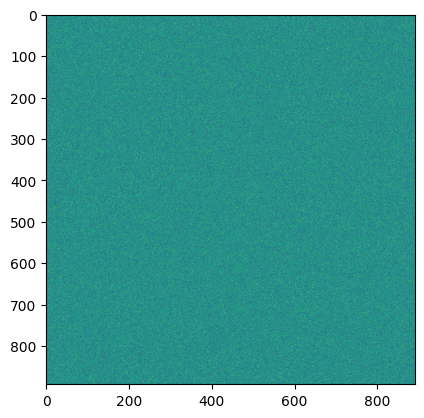

In [132]:
#6.5
hdulist = fits.open("noisemap0.fits")
dat0 = hdulist[0].data
newdat0 = np.asarray(dat0, dtype=float)
std0 = np.std(newdat0)
print(f"The standard deviation of noisemap0 is: {std0}")
hdulist.close()

hdulist = fits.open("noisemap1.fits")
dat1 = hdulist[0].data
newdat1 = np.asarray(dat1, dtype=float)
std1 = np.std(newdat1)
print(f"The standard deviation of noisemap0 is: {std1}")
hdulist.close()

hdulist = fits.open("noisemap2.fits")
dat2 = hdulist[0].data
newdat2 = np.asarray(dat2, dtype=float)
std2 = np.std(newdat2)
print(f"The standard deviation of noisemap0 is: {std2}")
hdulist.close()

stacked = np.stack((dat0,dat1,dat2),axis=-1)
meanstack = np.mean(stacked, axis =-1)
meanstack_flat = meanstack.flatten()
plt.imshow(meanstack)
meanstdnp = np.std(meanstack_flat)
meanstd = 1/3*((std0**2+std1**2+std2**2)**0.5)
print(f"The std from the stacked data is: {meanstdnp}, and the std corresponding to the calculation is: {meanstd}.")

In [139]:
#6.6
hdul = fits.open("~/PROGNUM-repo/Task4/APOGEE_stars.fits")
hdul.info()
data = hdul[1].data
colnames = hdul[1].columns.names

mask = (
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)

DATAFLAG = np.zeros(len(data), dtype = int) #Sets it to zero.
DATAFLAG[mask]=1 #Changes the 0 to 1 IF the data holds ALL conditions.



Filename: /Users/users/wroosterhof/PROGNUM-repo/Task4/APOGEE_stars.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (847,)   uint8   
  1  /Users/sunnyc/Downloads/allStar-dr17-synspec_rev1.fits#1    1 BinTableHDU     28   733901R x 8C   [E, E, E, E, E, K, K, E]   


* When you read an image you can plot is, while reading a table you get a table.
* The difference in  the data structure is that the tabel only specifies 1 dimension, while an image specifies 2 and the format of the numbers are different in this case.
